In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse

from convolution_as_MPO import construct_convolution_MPO

import importlib
import sys
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Chebyshev')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/TCI')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Correlation_function')
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Chebyshev")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/TCI")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Correlation_function")


import ED_Cs_Lsites as ED
import TCI_singlesite as TCI_single
import TCI_Lsite_accumulative_v1 as TCI_multi
import tensor_cross_interpolation as tci
import MPS 
import Chebyshev as Cheby

importlib.reload(ED)
importlib.reload(TCI_single)
importlib.reload(TCI_multi)
importlib.reload(MPS)
importlib.reload(Cheby)

<module 'Chebyshev' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Chebyshev/Chebyshev.py'>

## TCI algorithm on noisy data

In [13]:
# define Hamiltonian terms
L = 11
n = 11
dt = 1e-2
models = ['J = 1, g = 2 , Ising Model Ham. = H','J =1 g = 2 Ham. = H - k*Hzz', 'J = 1 g = 0.5, Ham. = H - h * Hxx', 'J = 1 g = 0.5, Ham. = H - k*Hzz - h*Hxx']
threshold = 30
N = 2**n
D = L
g_par = 0.1


In [3]:
# Generate Hamiltonian
Hlist = [ED.gen_Ham(L = L, model = 0), ED.gen_Ham(L = L, model = 2)]

In [4]:
Cs_theo = ED.correlator(H= Hlist[0], L = L, dt = dt,  n = n)
print(Cs_theo.shape)

for i in range(Cs_theo.shape[0]):
    for k in range(Cs_theo.shape[1]):
        if Cs_theo.real[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = 1. + 1j* Cs_theo.imag[i,k]
        if Cs_theo.imag[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = Cs_theo.real[i,k] + 1j

Expectation value $\bra{\psi_0} X_{L/2} \ket{psi_0}$=  1.9365925444093488e-16
(11, 2048)
i,k: ( 5 , 0 ),  (1.0000000000000038+0j)


In [5]:
N_shots = 2**13 #8192 rough estimation by Bernhard
# clip to avoid tiny negative values from rounding
std_real = np.sqrt(np.clip(1 - Cs_theo.real**2, 0, None)) / np.sqrt(N_shots)
std_imag = np.sqrt(np.clip(1 - Cs_theo.imag**2, 0, None)) / np.sqrt(N_shots)

np.random.seed(0)  # optional
Cs_noise_real = np.random.normal(loc=0.0, scale=std_real)
Cs_noise_imag = np.random.normal(loc=0.0, scale=std_imag)

print(Cs_noise_real[0])

Cs_noise = Cs_theo + Cs_noise_real + 1j * Cs_noise_imag
print("shapes:", Cs_theo.shape, Cs_noise.shape)

[ 0.01948883  0.00442084  0.01081286 ...  0.00108669 -0.00514087
  0.01373149]
shapes: (11, 2048) (11, 2048)


In [6]:
diff_noisevstheo = Cs_theo-Cs_noise #should be difference between 2 matrices
err_max_noisevstheo = np.max(np.abs(diff_noisevstheo))/np.max(np.abs(Cs_theo))
print("Max error (noise vs theo): ", err_max_noisevstheo)
err_2_noisevstheo = np.linalg.norm(diff_noisevstheo)/np.linalg.norm(Cs_theo)
print("2-norm error (noise vs theo): ", err_2_noisevstheo)

Max error (noise vs theo):  0.051442664338269994
2-norm error (noise vs theo):  0.04675541920299879


In [7]:
# D = L #already defined above

func_vals_theo = Cs_theo.T #Cs is in the form (X,T)
func_vals_noise = Cs_noise.T

#first we define the function f(t)
# which returns the slice of func_vals along x for a specific time 
f_t_theo = lambda *t: Cs_theo.reshape((D,) + (2,) * n)[:,*t]
f_t_noise = lambda *t: Cs_noise.reshape((D,) + (2,) * n)[:,*t]

In [8]:
func_noise = TCI_multi.function(f_t_noise)
chi = 15

As, _, eval, err_2, err_max, func_interp_noise = TCI_multi.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.05624551701838599
err_2:  0.0540010002742706

repeated evaluations:  43750
unique evaluations 1410
unique + repeated:  45160
total evaluations:  45160



## Convolution part

In [9]:
# define some helper functions
def contract_MPS(Ms):
    vals = np.squeeze(Ms[0])
    for M in Ms[1:]:
        vals = np.einsum('ia, ajb -> ijb', vals, M)
        vals = vals.reshape(-1, M.shape[-1])
    vals = vals.reshape(-1)
    return vals

In [10]:
# Create Gaussian windowing function
def Gaussian(x, var=1e-5):
    return np.exp(- (x - 0.5)**2 / (2 * var) ) / np.sqrt(2 * np.pi * var)

def tensorized_Gaussian(*args):
    L = len(args)
    bits = 2.**np.arange(-1, -L-1, -1)
    x = np.sum(np.array(args) * bits)
    val = Gaussian(x)
    return val

# evaluate full function
n = 11
xs = np.arange(2**n) / 2**n
Gauss_vals = Gaussian(xs)
# Gauss_vals = Gauss_vals / np.sum(Gauss_vals) # normalize to sum to 1

new_func = TCI_single.function(tensorized_Gaussian)

# for i in range(200):
#     print(Gauss_vals[i])

# print()

# for i in [0,1]:
#     for j in [0,1]:
#         for k in [0,1]:
#             for l in [0,1]:
#                 print(new_func(0,0,0,0,0,0,0,i,j,k,l))

[array([], shape=(1, 0), dtype=int64), array([[1],
       [0]]), array([[1, 0],
       [1, 1]]), array([[1, 0, 0],
       [1, 0, 1]]), array([[1, 0, 0, 0],
       [1, 0, 0, 1]]), array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 1]]), array([[1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 1]]), array([[1, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 1]]), array([[1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1]]), array([[1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0]]), array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0]])]
[array([], shape=(1, 0), dtype=int64), array([[1],
       [0]]), array([[1, 0],
       [1, 1],
       [0, 0],
       [0, 1]]), array([[1, 0, 0],
       [0, 1, 1],
       [1, 1, 0],
       [1, 1, 1],
       [0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 1]]), array([[1, 0, 0, 0],
       [0, 1, 1, 1],
       [1, 0, 0, 1],
       [0, 1, 1, 0],
       [1, 1, 0, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 0],
       [1, 

/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


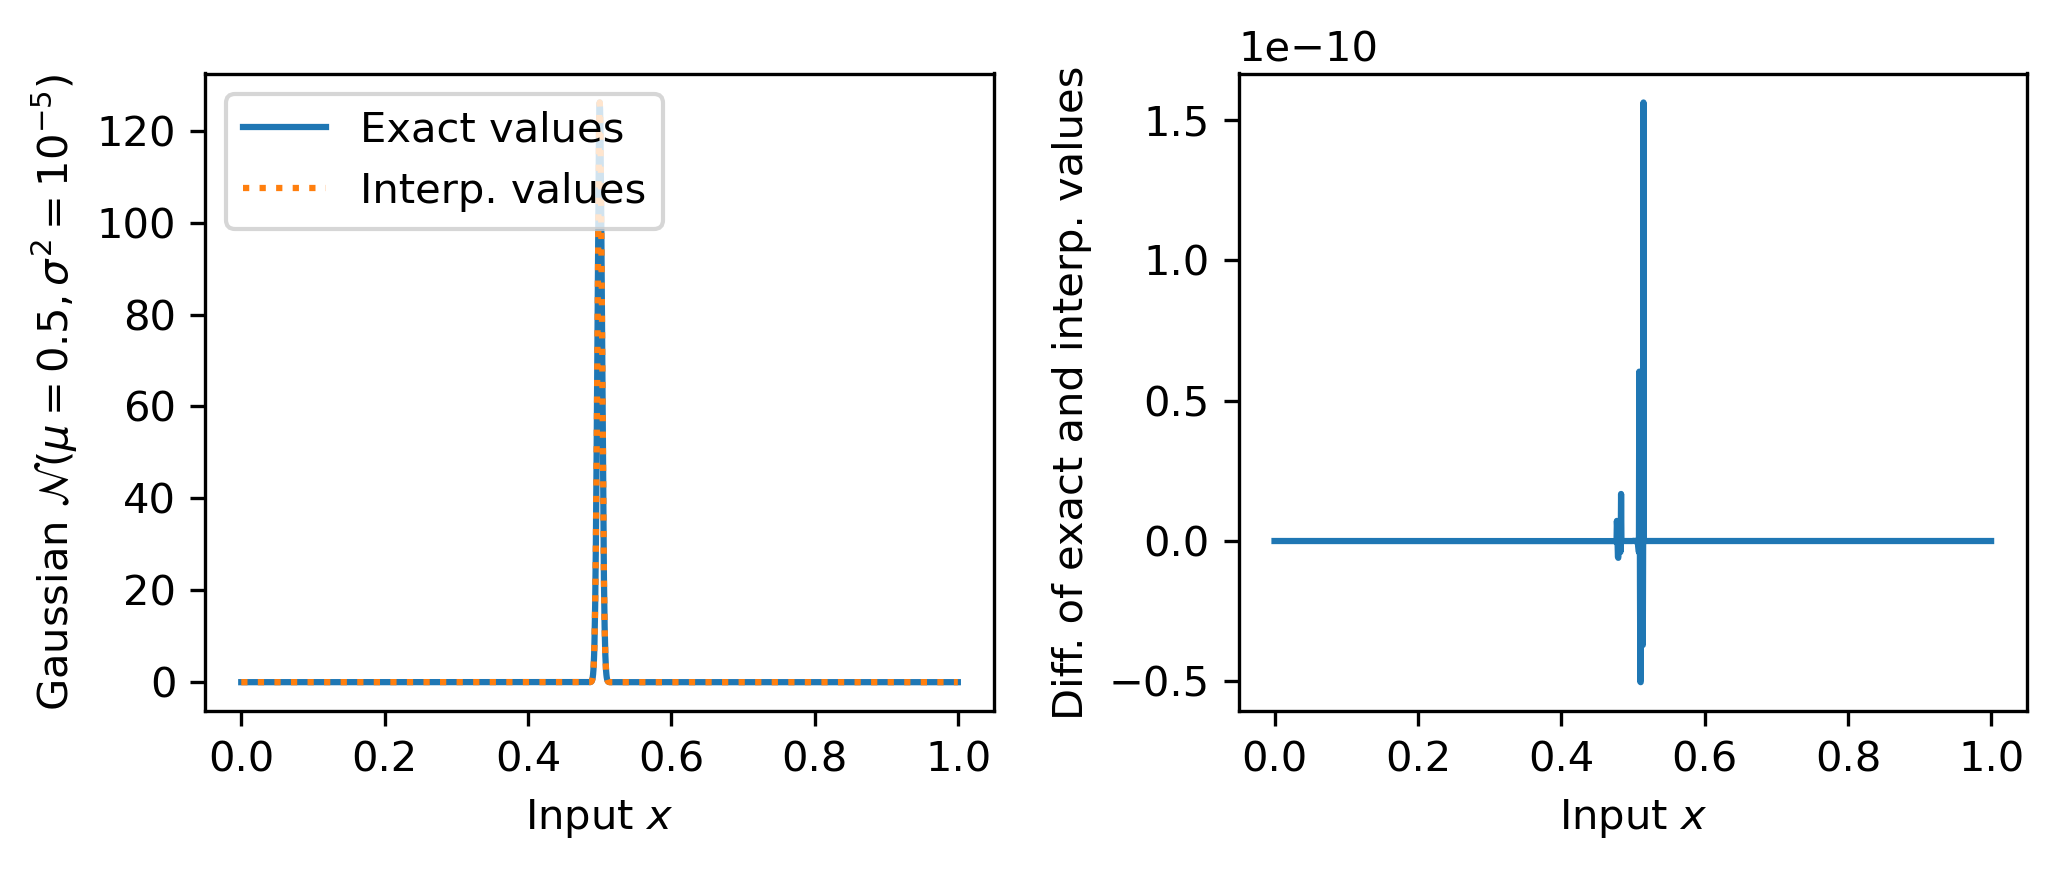

In [11]:
# interpolate function (Gaussian is sparse, start the TCI at x=0.5 for stability)
Gs, _, _, _, _ = TCI_single.tensor_cross_interpolation(new_func,         # function to be interpolated
                                Gauss_vals,      
                                L=n,          # number of MPS tensors
                                eps_or_chi=8, # bond dimension
                                iters=6,
                                init_idxs=[1]+[0]*(L-1))       # number of back-and-forth sweeps


# Gs, _, _ = tci.tensor_cross_interpolation(tensorized_Gaussian,
#                                           L=n,
#                                           mode='reset',
#                                           cache=False,
#                                           init_idxs=[1]+[0]*(L-1),
#                                           eps_or_chi=8,
#                                           num_sweeps=6)

GMPS_vals = contract_MPS(Gs)

fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)

axs[0].plot(xs, Gauss_vals, '-', label='Exact values')
axs[0].plot(xs, GMPS_vals, ':', label='Interp. values')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Gaussian $\mathcal{N}(\mu=0.5, \sigma^2=10^{-5})$')
axs[0].legend(loc='upper left')

axs[1].plot(xs, Gauss_vals - GMPS_vals, '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and interp. values')

plt.tight_layout()
plt.show()

### Chebyshev

a, b:  2 2000


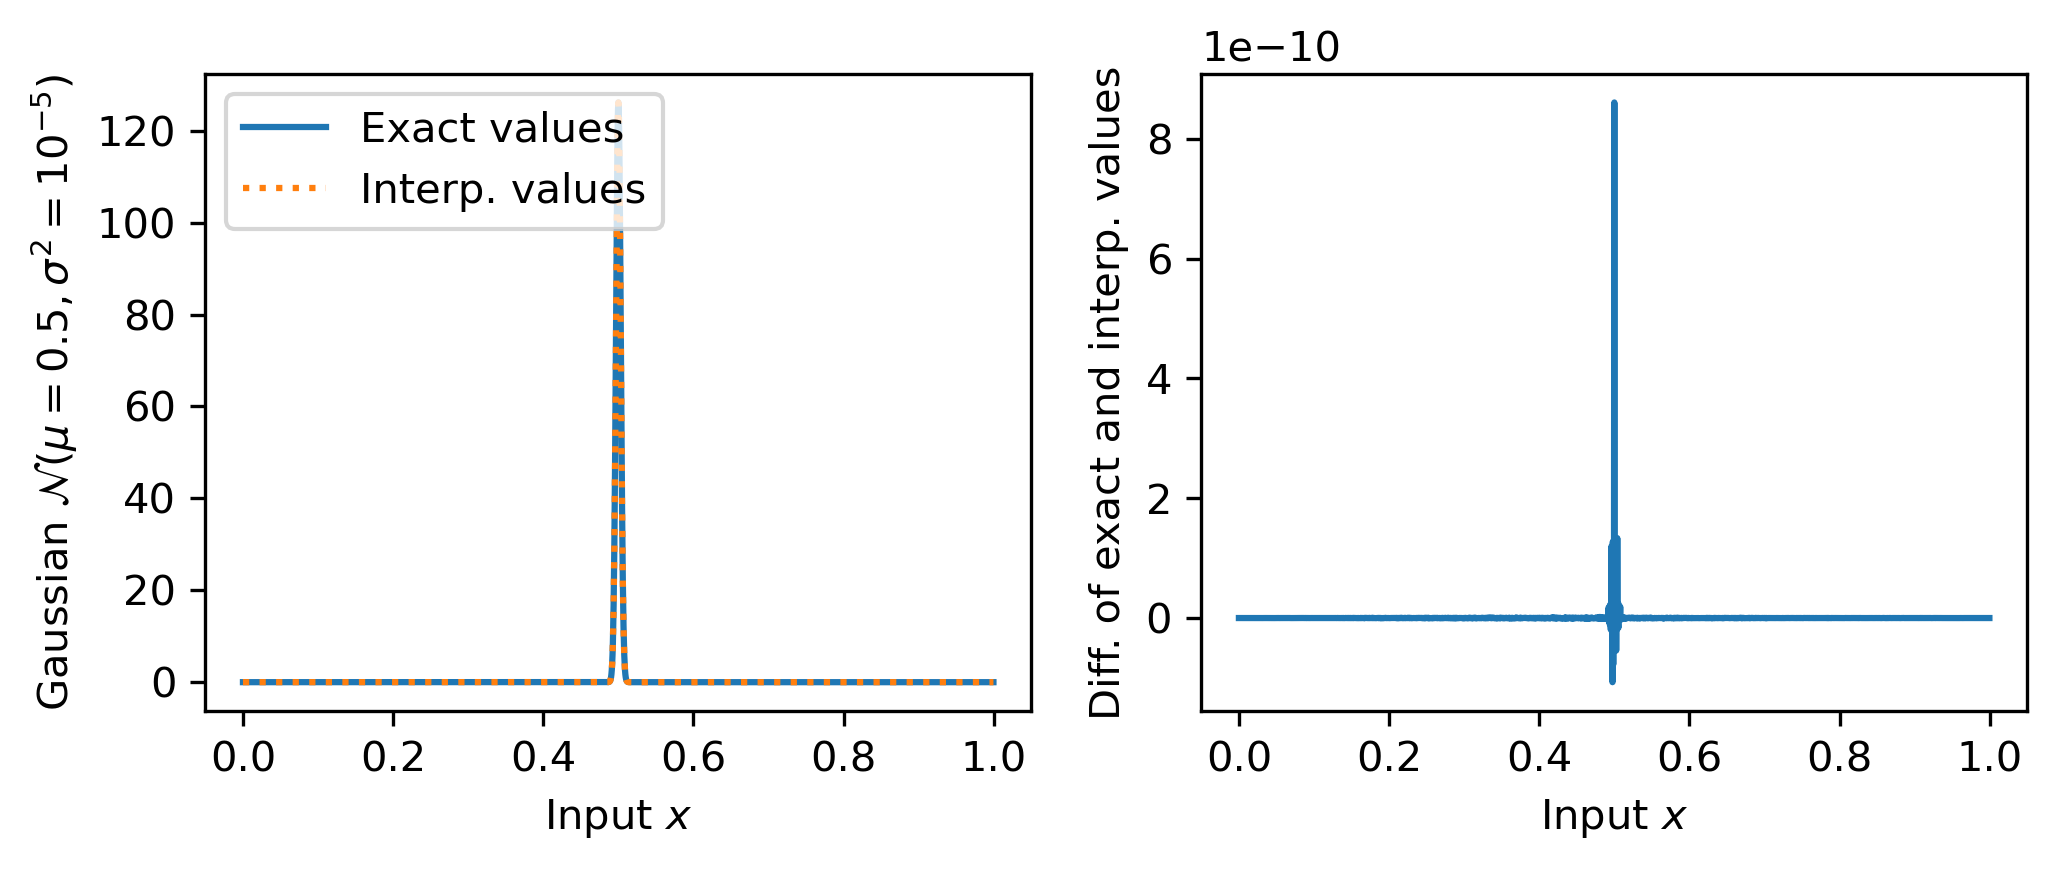

In [133]:
# Create Gaussian windowing function
def Gaussian(x, var=1e-5):
    return np.exp(- (x - 0.5)**2 / (2 * var) ) / np.sqrt(2 * np.pi * var)


def cheby_Gaussian(mat):
    a, b = mat.shape
    print("a, b: ", a, b)
    t = mat.reshape(-1)
    arr = Gaussian(t)
    return arr.reshape(a, b)

# evaluate full function
L = 11
xs = np.arange(2**L) / 2**L
Gauss_vals = Gaussian(xs)

As, _, _, _, GMPS_vals = Cheby.Chebyshev_interpolation(cheby_Gaussian, 
                                                    Gauss_vals, 
                                                    L=L, 
                                                    chi=2000)

fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)

axs[0].plot(xs, Gauss_vals, '-', label='Exact values')
axs[0].plot(xs, GMPS_vals, ':', label='Interp. values')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Gaussian $\mathcal{N}(\mu=0.5, \sigma^2=10^{-5})$')
axs[0].legend(loc='upper left')

axs[1].plot(xs, Gauss_vals - GMPS_vals, '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and interp. values')

plt.tight_layout()
plt.show()

In [34]:
for A in As:
    print(A.shape)

(11, 1, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 15)
(15, 2, 8)
(8, 2, 4)
(4, 2, 2)
(2, 2, 1)


In [73]:
def apply_MPO(MPO, MPS):
    Ms = []
    for W, M in zip(MPO, MPS):
        # Flatten any extra leading dimensions (e.g., (1, 1, 2, 8) becomes (1, 2, 8))
        if M.ndim > 3:
            M = M.reshape(-1, M.shape[-2], M.shape[-1])
            
        chilW, chirW, d, _ = W.shape
        chilM, _, chirM = M.shape
        
        # Apply the contraction
        new_M = np.einsum('abkj, cjd -> ackbd', W, M)
        
        # Reshape to standard 3-leg MPS format
        Ms.append(new_M.reshape(chilW * chilM, d, chirW * chirM))
        
    return Ms

In [74]:
Ws = construct_convolution_MPO(L, conv_MPS = Gs)
conv_As = apply_MPO(Ws, As)
conv_MPS_vals = MPS.interpolate_func(conv_As)


In [75]:
conv_func_interp = np.zeros_like(func_interp_noise)

for i in range(func_interp_noise.shape[1]):
    conv_func_interp[:, i] = np.convolve(func_interp_noise[:, i], Gauss_vals, mode='same')

In [77]:
# Crea un array vuoto con le stesse dimensioni per salvare il risultato
conv_func_vals = np.zeros_like(func_vals_noise)


# Applica la convoluzione 1D indipendentemente per ognuna delle 11 colonne
for i in range(func_vals_noise.shape[1]):
    conv_func_vals[:, i] = np.convolve(func_vals_noise[:, i], Gauss_vals, mode='same')

# # Calculate the exact numerical sum of the Gaussian array
# normalization_factor = np.sum(Gauss_vals)

# # Normalize the exact convolution
# conv_func_vals_normalized = conv_func_vals / normalization_factor

# # Normalize the MPS convolution
# conv_MPS_vals_normalized = conv_MPS_vals / normalization_factor

/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


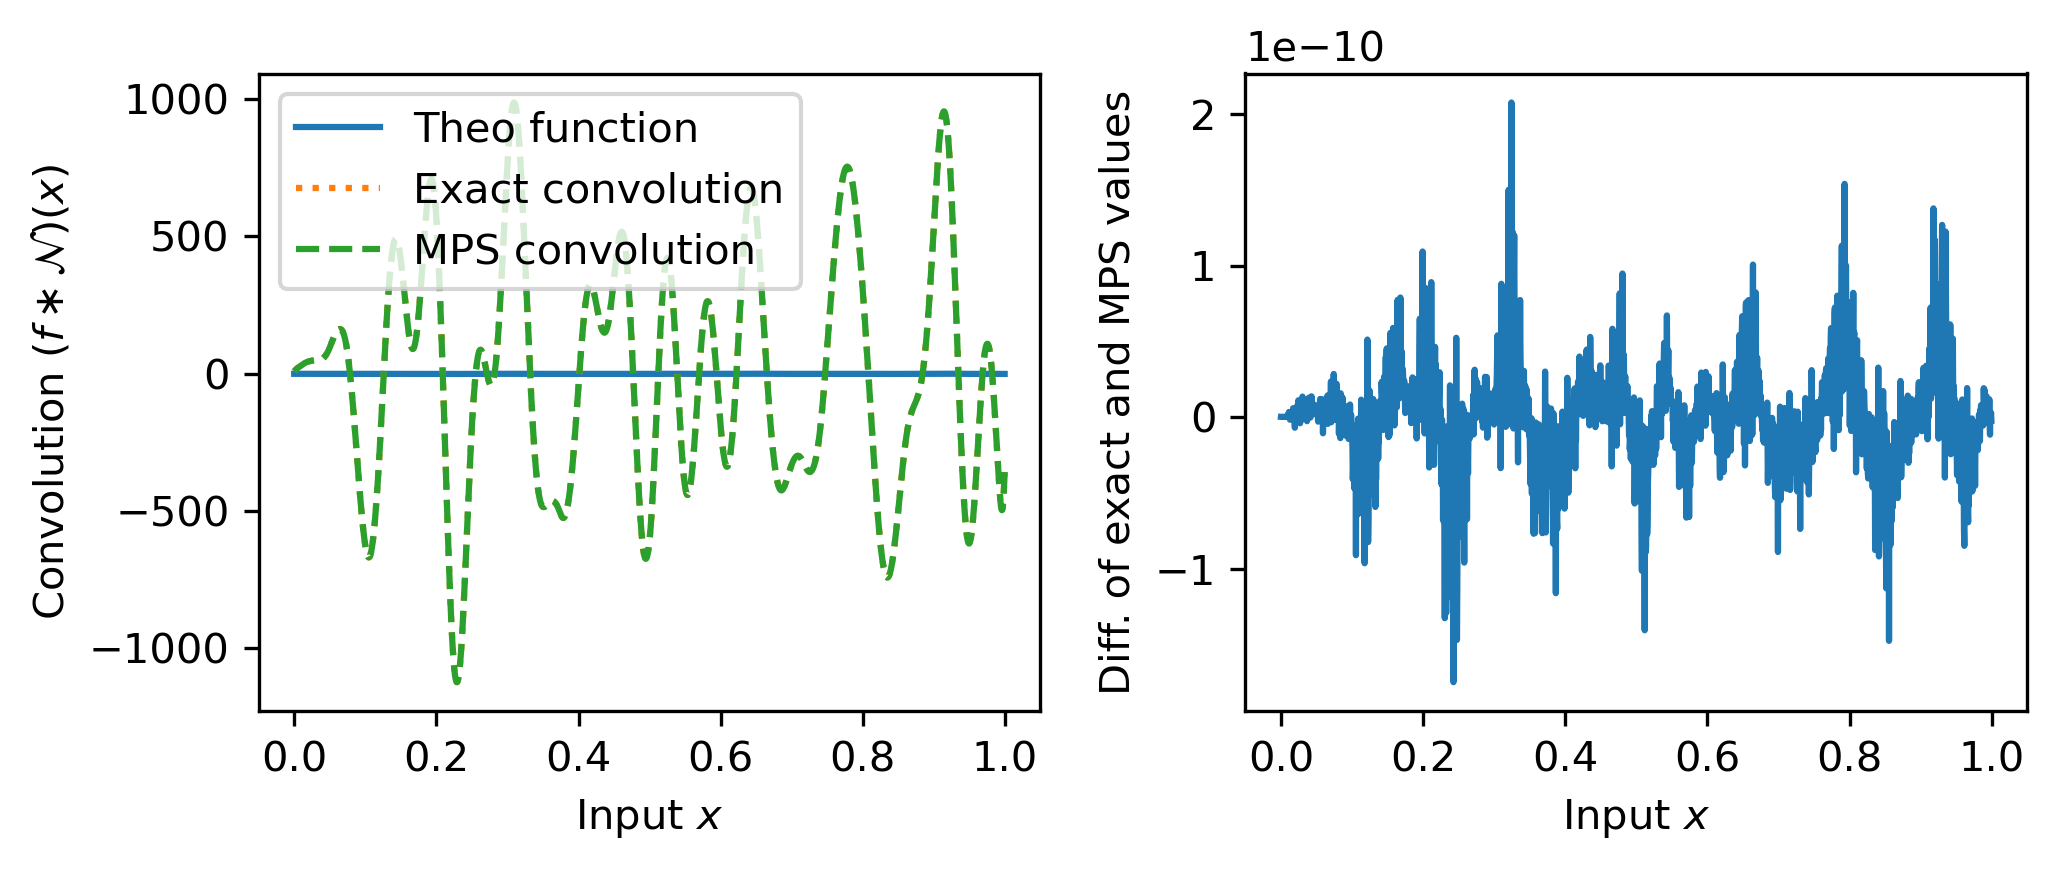

In [79]:
# Scegli l'indice spaziale/temporale da visualizzare nel plot
idx_to_plot = 1

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(xs, func_vals_theo[:, idx_to_plot], '-', label='Theo function')
axs[0].plot(xs, conv_func_interp[:, idx_to_plot], ':', label='Exact convolution')
axs[0].plot(xs, conv_MPS_vals[:, idx_to_plot], '--', label='MPS convolution')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].legend(loc='upper left')

axs[1].plot(xs, conv_func_interp[:, idx_to_plot] - conv_MPS_vals[:, idx_to_plot], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

# axs[1].plot(xs, func_vals_theo[:, idx_to_plot] - conv_MPS_vals_normalized[:, idx_to_plot], '-')
# axs[1].set(xlabel=r'Input $x$',
#            ylabel='Diff. of theo and conv MPS values')
plt.tight_layout()
plt.show()

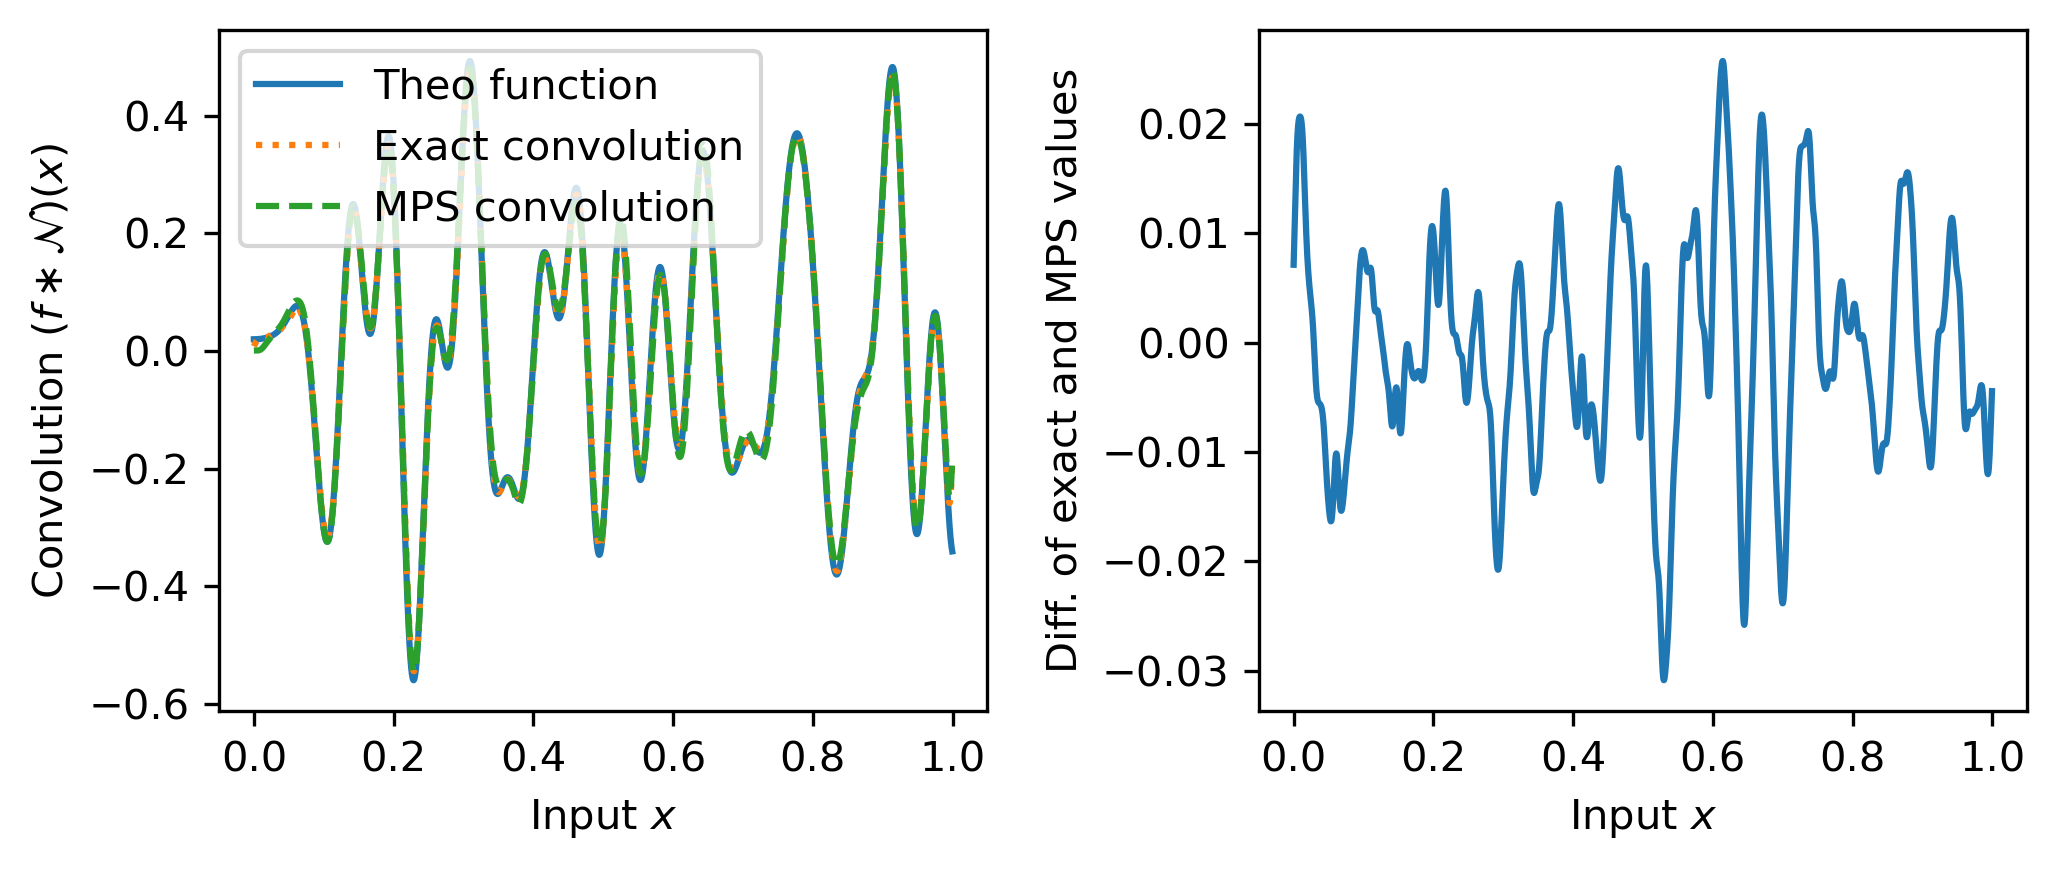

In [84]:
# Scegli l'indice spaziale/temporale da visualizzare nel plot
idx_to_plot = 1

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(xs, func_vals_theo[:, idx_to_plot], '-', label='Theo function')
axs[0].plot(xs, conv_func_vals_normalized[:, idx_to_plot], ':', label='Exact convolution')
axs[0].plot(xs, conv_MPS_vals_normalized[:, idx_to_plot], '--', label='MPS convolution')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].legend(loc='upper left')

axs[1].plot(xs, conv_func_vals_normalized[:, idx_to_plot] - conv_MPS_vals_normalized[:, idx_to_plot], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

# axs[1].plot(xs, func_vals_theo[:, idx_to_plot] - conv_MPS_vals_normalized[:, idx_to_plot], '-')
# axs[1].set(xlabel=r'Input $x$',
#            ylabel='Diff. of theo and conv MPS values')
plt.tight_layout()
plt.show()

In [79]:
print(func_vals_theo.shape)
print(conv_func_vals_normalized.shape)
print(conv_MPS_vals_normalized.shape)

(2048, 11)
(2048, 11)
(2048, 11)


In [80]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_conv_noise, err_2_conv_noise = MPS.errors(conv_MPS_vals_normalized, func_vals_noise, interpolate=False)
err_max_conv_theo, err_2_conv_theo = MPS.errors(conv_MPS_vals_normalized, func_vals_theo, interpolate=False)

In [81]:
print("Max error vs theo function (tci vs MPS conv): ", f"{err_max_theo:.4f}", f"{err_max_conv_theo:.4f}")
print("2-norm error vs theo function (tci vs MPS conv): ", f"{err_2_theo:.4f}", f"{err_2_conv_theo:.4f}")
print()
print("Max error vs noisy function (tci vs MPS conv): ", f"{err_max:.4f}", f"{err_max_conv_noise:.4f}")
print("2-norm error vs noisy function (tci vs MPS conv): ", f"{err_2:.4f}", f"{err_2_conv_noise:.4f}")

Max error vs theo function (tci vs MPS conv):  0.0389 0.5490
2-norm error vs theo function (tci vs MPS conv):  0.0461 0.0724

Max error vs noisy function (tci vs MPS conv):  0.0638 0.5458
2-norm error vs noisy function (tci vs MPS conv):  0.0648 0.0857


In [82]:
import numpy as np

# ---------------------------------------------------------
# 1. HELPER: Crop the padded MPS back to original size
# ---------------------------------------------------------
def crop_mps_msb(mps_padded):
    """
    Crops a 2^(n+1) sized MPS down to 2^n by projecting the 
    Most Significant Bit (MSB) to the |0> state.
    
    Assumes `mps_padded` is a list of tensors with shape 
    (chi_left, phys_dim, chi_right) and that the MSB is the FIRST tensor (index 0).
    """
    # The |0> state projector
    projector_0 = np.array([1.0, 0.0])
    
    first_tensor = mps_padded[0] # Shape: (1, 2, chi)
    
    # Contract the physical leg of the first tensor with |0>
    # Resulting shape: (1, chi)
    cropped_edge = np.einsum('lpr, p -> lr', first_tensor, projector_0)
    
    # Absorb this boundary into the next tensor to remove the site completely
    second_tensor = mps_padded[1] # Shape: (chi, 2, chi_next)
    
    # Contract: (1, chi) x (chi, 2, chi_next) -> (1, 2, chi_next)
    new_first_tensor = np.einsum('lc, cpr -> lpr', cropped_edge, second_tensor)
    
    # Reassemble the MPS, which is now 1 site shorter (original size n)
    mps_cropped = [new_first_tensor] + mps_padded[2:]
    
    return mps_cropped

# ---------------------------------------------------------
# 2. MAIN PROCEDURE: Zero-Padded Convolution
# ---------------------------------------------------------
def execute_linear_convolution_mpo(f_vals, g_vals, n_qubits):
    """
    Executes a linear convolution using the periodic MPO by zero-padding.
    
    f_vals, g_vals: 1D numpy arrays of size 2^n evaluated on your domain
    n_qubits: The original number of qubits 'n' (before padding)
    """
    N_original = 2**n_qubits
    
    # -- STEP 1: Increase system size --
    n_padded = n_qubits + 1
    N_padded = 2**n_padded
    
    # -- STEP 2: Zero-pad the input arrays --
    # np.pad adds N_original zeros to the end of the arrays
    f_padded = np.pad(f_vals, (0, N_original), mode='constant', constant_values=0)
    g_padded = np.pad(g_vals, (0, N_original), mode='constant', constant_values=0)
    
    # -- STEP 3: Convert to MPS --
    # NOTE: Replace 'array_to_mps' with your actual function (e.g., from TCI 
    # or exact SVD from your MPS.py script)
    # mps_f_padded = array_to_mps(f_padded, n_qubits=n_padded)
    # mps_g_padded = array_to_mps(g_padded, n_qubits=n_padded)
    
    # -- STEP 4: Build extended MPO --
    # Call your function from convolution_as_MPO.py using the padded size
    # conv_mpo_padded = construct_convolution_MPO(n_padded)
    
    # -- STEP 5: Apply Convolution --
    # Contract the MPO with your two input MPSs. 
    # mps_result_padded = apply_mpo_to_mps(conv_mpo_padded, mps_f_padded, mps_g_padded)
    
    # -- STEP 6: Crop back to original domain --
    # mps_final_cropped = crop_mps_msb(mps_result_padded)
    
    print(f"Original size: {N_original} (n={n_qubits})")
    print(f"Padded size: {N_padded} (n={n_padded})")
    print("Zero-padding and cropping successfully set up.")
    
    # Returning the padded arrays just so you can test the conversion
    # In practice, you will return `mps_final_cropped`
    return f_padded, g_padded # return mps_final_cropped